In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

from scipy.stats import hypergeom
import seaborn as sns

from scipy.stats import fisher_exact


In [ ]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'

adata = sc.read_h5ad(adata_path)


In [3]:
adata.obs[['chr7_copy_number','chr10_copy_number']] = pd.read_csv('../output/chr7_chr10_copy_number_infercnv.txt', sep='\t', index_col=0)
adata.obs['chr7_CNV'] = (adata.obs['chr7_copy_number'] > 0.014).map({True: 2, False: 1})
adata.obs['chr10_CNV'] = (adata.obs['chr10_copy_number'] < (-0.004)).map({True: 2, False: 1})

In [4]:
adata.obs['cell_type'] = pd.read_csv('../output/GBM_cell_type_labels.txt', sep='\t', index_col=0)


In [ ]:
gf_utils.assign_genotypes(adata, min_counts=0, min_p=0.6)

In [6]:
## subset to only cancer cells
adata = adata[adata.obs['cell_type'].isin(['NPC','AC','OPC','MES'])].copy()


In [7]:
### check mutation co-occurrence

target1 = 'EGFR c.1889_1894delinsTAGGAT'
target2 = 'EGFR c.685A>T'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=0.12448132780082988, pvalue=1.2956198015615365e-06)
SignificanceResult(statistic=0.12448132780082988, pvalue=0.9999998479154872)


In [8]:
target1 = 'EGFR c.1889_1894delinsTAGGAT'
target2 = 'AXL c.1103G>A'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=3.3506493506493507, pvalue=0.9953434861304775)
SignificanceResult(statistic=3.3506493506493507, pvalue=0.018752246290362977)


In [9]:
target1 = 'EGFR c.1889_1894delinsTAGGAT'
target2 = 'EGFR VIII'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=0.06764538603725295, pvalue=3.211913843318031e-05)
SignificanceResult(statistic=0.06764538603725295, pvalue=0.9999980044167149)


In [10]:
target1 = 'EGFR VIII'
target2 = 'EGFR c.685A>T'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=0.0, pvalue=0.43849269240461763)
SignificanceResult(statistic=0.0, pvalue=1.0)


In [11]:
target1 = 'AXL c.1103G>A'
target2 = 'EGFR VIII'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=0.0, pvalue=0.20413333806966139)
SignificanceResult(statistic=0.0, pvalue=1.0)


In [12]:
target1 = 'AXL c.1103G>A'
target2 = 'EGFR c.685A>T'

table = np.array([[((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  ((adata.obsm['genotype_call'][target1] == 'wt') & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()],
                  [(adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2] == 'wt')).sum(),
                  (adata.obsm['genotype_call'][target1].isin(['mutated','heterozygous']) & (adata.obsm['genotype_call'][target2].isin(['mutated','heterozygous']))).sum()]])

print(fisher_exact(table, alternative='less'))
print(fisher_exact(table, alternative='greater'))


SignificanceResult(statistic=0.0, pvalue=0.36689122055372736)
SignificanceResult(statistic=0.0, pvalue=1.0)


/tmp/ipykernel_2025652/282338774.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'wt':1,'heterozygous':2,'mutated':2})


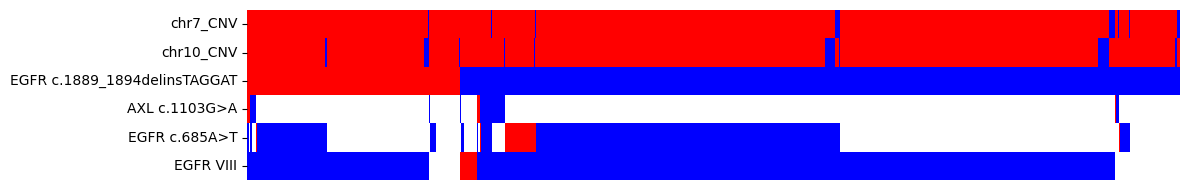

In [13]:
target1 = 'EGFR c.1889_1894delinsTAGGAT'
target2 = 'EGFR VIII'
target4 = 'EGFR c.685A>T'
target3 = 'AXL c.1103G>A'

df = adata.obsm['genotype_call'][[target1,target2,target3,target4]]
df.loc[:,['chr7_CNV','chr10_CNV']] = adata.obs[['chr7_CNV','chr10_CNV']].copy()

df = df.loc[df[target1].notna()].reset_index(drop=True)

df = df.replace({'wt':1,'heterozygous':2,'mutated':2})
df = df.sort_values([target1,target2,target3,target4,'chr7_CNV','chr10_CNV'],ascending=False)
df.reset_index(inplace=True, drop=True)

df = df[['chr7_CNV','chr10_CNV','EGFR c.1889_1894delinsTAGGAT','AXL c.1103G>A','EGFR c.685A>T','EGFR VIII']]
fig,ax = plt.subplots(figsize=(12,2))
cmap = matplotlib.colors.ListedColormap(['blue', 'red'])
sns.heatmap(df.transpose(), cmap=cmap, cbar=False, ax=ax, alpha=1)
plt.gca().set_xticks([])
plt.xlabel('')
plt.tight_layout()

plt.savefig('../plots/cooccurrence_all_mutations.pdf')